# Pretrained HAT-Based PAN Fusion — Stable Float32 Version

## الهدف

مقارنة الـFusion CNN السابق بنموذج يعتمد على HAT.

لدينا في كل عينة:

```text
LR-MS: 6 × 64 × 64 عند 4.8 m/pixel
PAN:   1 × 256 × 256 عند 1.2 m/pixel
Target MS: 6 × 256 × 256 عند 1.2 m/pixel
```

الموديل المقترح:

```text
LR-MS 6×64×64
+
PAN بعد تصغيرها إلى 64×64
        ↓ Concatenate
7×64×64
        ↓ Pretrained HAT ×4
HAT residual: 6×256×256
        +
Bicubic LR-MS: 6×256×256
        ↓
Coarse MS
        +
Original PAN 1×256×256
        ↓ CNN Refinement
Final MS: 6×256×256
```

## لماذا نستخدم PAN مرتين؟

- PAN المصغرة تدخل إلى HAT حتى يرى النموذج العلاقة العامة بين MS وPAN.
- PAN الأصلية بدقة أعلى تدخل إلى Refinement Head لاستعادة التفاصيل المكانية الدقيقة.

## مراحل التدريب

### Stage A

تجميد جسم HAT المدرّب مسبقًا وتدريب:

- HAT output layer الجديدة: `64 → 6`.
- PAN refinement head.

### Stage B

فك تجميد آخر مجموعتين من HAT مع طبقات إعادة البناء، ثم Fine-tuning بمعدل تعلم أصغر.

> هذه التجربة تستخدم نفس L1 Loss ونفس Normalization ونفس Train/Val/Test الخاصة بالـFusion CNN، حتى تكون المقارنة أقرب للعدالة.


## إصلاحات الاستقرار في هذه النسخة

- `NUM_WORKERS = 0` لتجنب خطأ child process في Colab.
- تعطيل AMP/FP16 أثناء تدريب HAT.
- تعطيل DropPath في HAT المعدل.
- تقليل Learning Rate.
- فحص `NaN/Inf` في الناتج والـLoss والـGradients.
- حذف Checkpoints القديمة قبل إعادة التدريب.


## 1) تفعيل GPU

في Colab:

```text
Runtime → Change runtime type → T4 GPU
```


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("شغّل الـNotebook باستخدام GPU.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2) تثبيت HAT والمكتبات

In [2]:
from pathlib import Path
import shutil
import subprocess
import sys

%cd /content

HAT_REPO = Path("/content/HAT")

if HAT_REPO.exists():
    shutil.rmtree(HAT_REPO)

subprocess.run(
    [
        "git",
        "clone",
        "--depth",
        "1",
        "https://github.com/XPixelGroup/HAT.git",
        str(HAT_REPO),
    ],
    check=True,
)

%cd /content/HAT

!pip install -q -r requirements.txt
!pip install -q -e .
!pip install -q numpy matplotlib tqdm scikit-image

# توافق BasicSR مع torchvision الحديثة في Colab
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

print("Installation completed.")


/content
/content/HAT
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 25.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installation completed.


## 3) تنزيل HAT ×4 Pretrained Weights

In [3]:
WEIGHT_DIR = HAT_REPO / "experiments" / "pretrained_models"
WEIGHT_DIR.mkdir(parents=True, exist_ok=True)

WEIGHT_PATH = WEIGHT_DIR / "HAT_SRx4_ImageNet-pretrain.pth"

if not WEIGHT_PATH.exists():
    !wget -q --show-progress       -O "{WEIGHT_PATH}"       "https://huggingface.co/Acly/hat/resolve/main/HAT_SRx4_ImageNet-pretrain.pth"

print("Weight:", WEIGHT_PATH)
print("Size MB:", round(WEIGHT_PATH.stat().st_size / 1024**2, 2))


/content/HAT/experi 100%[===================>]  81.19M  23.2MB/s    in 3.9s    
Weight: /content/HAT/experiments/pretrained_models/HAT_SRx4_ImageNet-pretrain.pth
Size MB: 81.19


## 4) ربط Google Drive والمسارات

In [4]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

DATA_DIR = PROJECT_DIR / "Wald_Data_GSD" / "Patches"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

BASELINE_DIR = PROJECT_DIR / "Fusion_Baseline_Results"
BASELINE_STATS_PATH = BASELINE_DIR / "train_normalization_stats.json"
BASELINE_METRICS_PATH = BASELINE_DIR / "test_metrics.json"

OUTPUT_DIR = PROJECT_DIR / "HAT_PAN_Fusion_Results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_A_MODEL = OUTPUT_DIR / "best_hat_stage_a.pth"
BEST_MODEL_PATH = OUTPUT_DIR / "best_hat_pan_fusion.pth"
LAST_MODEL_PATH = OUTPUT_DIR / "last_hat_pan_fusion.pth"
HISTORY_PATH = OUTPUT_DIR / "hat_training_history.json"
TEST_METRICS_PATH = OUTPUT_DIR / "hat_test_metrics.json"

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not folder.exists():
        raise FileNotFoundError(folder)

if not BASELINE_STATS_PATH.exists():
    raise FileNotFoundError(
        "لم أجد train_normalization_stats.json الناتج من Notebook الـFusion CNN."
    )

print("Train:", TRAIN_DIR)
print("Val  :", VAL_DIR)
print("Test :", TEST_DIR)
print("Output:", OUTPUT_DIR)


Mounted at /content/drive
Train: /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/train
Val  : /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/val
Test : /content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/test
Output: /content/drive/MyDrive/Super_Resolution_28-07-2026/HAT_PAN_Fusion_Results


## 5) إعدادات التدريب

In [5]:
import os
import random
import json
import numpy as np

SEED = 42

BATCH_SIZE = 1
ACCUMULATION_STEPS = 4
NUM_WORKERS = 0

# ابدأ بهذه القيم. يمكن زيادتها لاحقًا.
STAGE_A_EPOCHS = 5
STAGE_B_EPOCHS = 10

STAGE_A_LR = 5e-5
STAGE_B_LR = 1e-5

WEIGHT_DECAY = 1e-6

# HAT attention is trained in full float32 for numerical stability.
USE_AMP = False

SCALE = 4
MS_BANDS = 6

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

print("Device:", device)
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)


Device: cuda
Effective batch size: 4


## 6) تحميل Normalization المستخدمة في الـCNN

In [6]:
with open(BASELINE_STATS_PATH, "r", encoding="utf-8") as file:
    stats = json.load(file)

MS_LOW = np.array(
    [item["p01"] for item in stats["ms"]],
    dtype=np.float32,
)[:, None, None]

MS_HIGH = np.array(
    [item["p99"] for item in stats["ms"]],
    dtype=np.float32,
)[:, None, None]

PAN_LOW = np.float32(stats["pan"]["p01"])
PAN_HIGH = np.float32(stats["pan"]["p99"])


def normalize_ms(array):
    array = array.astype(np.float32)

    return np.clip(
        (array - MS_LOW) / (MS_HIGH - MS_LOW),
        0,
        1,
    )


def normalize_pan(array):
    array = array.astype(np.float32)

    return np.clip(
        (array - PAN_LOW) / (PAN_HIGH - PAN_LOW),
        0,
        1,
    )


print("Normalization loaded.")


Normalization loaded.


## 7) Dataset وDataLoader

In [7]:
from torch.utils.data import Dataset, DataLoader


class WaldPatchDataset(Dataset):
    def __init__(self, folder, augment=False):
        self.files = sorted(Path(folder).glob("*.npz"))
        self.augment = augment

        if not self.files:
            raise RuntimeError(f"No files in {folder}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file_path = self.files[index]

        with np.load(file_path) as sample:
            lr_ms = sample["lr_ms"].copy()
            pan = sample["pan"].copy()
            target = sample["target_ms"].copy()

        lr_ms = torch.from_numpy(normalize_ms(lr_ms)).float()
        pan = torch.from_numpy(normalize_pan(pan)).float()
        target = torch.from_numpy(normalize_ms(target)).float()

        if self.augment:
            if random.random() < 0.5:
                lr_ms = torch.flip(lr_ms, dims=[2])
                pan = torch.flip(pan, dims=[2])
                target = torch.flip(target, dims=[2])

            if random.random() < 0.5:
                lr_ms = torch.flip(lr_ms, dims=[1])
                pan = torch.flip(pan, dims=[1])
                target = torch.flip(target, dims=[1])

            rotations = random.randint(0, 3)

            if rotations:
                lr_ms = torch.rot90(lr_ms, rotations, dims=[1, 2])
                pan = torch.rot90(pan, rotations, dims=[1, 2])
                target = torch.rot90(target, rotations, dims=[1, 2])

        return {
            "lr_ms": lr_ms,
            "pan": pan,
            "target_ms": target,
            "file": file_path.name,
        }


train_dataset = WaldPatchDataset(TRAIN_DIR, augment=True)
val_dataset = WaldPatchDataset(VAL_DIR, augment=False)
test_dataset = WaldPatchDataset(TEST_DIR, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


Train samples: 231
Val samples  : 22
Test samples : 22


## 8) إنشاء HAT-PAN Fusion Model

In [8]:
import sys
import torch.nn as nn
import torch.nn.functional as F

sys.path.insert(0, str(HAT_REPO))

from hat.archs.hat_arch import HAT


class RefinementBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
        )

    def forward(self, x):
        return x + self.block(x)


class HATPanFusion(nn.Module):
    def __init__(self):
        super().__init__()

        # HAT branch: 7 LR channels → ×4 → 6-channel residual
        self.hat = HAT(
            upscale=4,
            in_chans=7,
            img_size=64,
            window_size=16,
            compress_ratio=3,
            squeeze_factor=30,
            conv_scale=0.01,
            overlap_ratio=0.5,
            img_range=1.0,
            depths=[6, 6, 6, 6, 6, 6],
            embed_dim=180,
            num_heads=[6, 6, 6, 6, 6, 6],
            mlp_ratio=2,
            upsampler="pixelshuffle",
            resi_connection="1conv",
            use_checkpoint=False,
            drop_path_rate=0.0,
        )

        # HAT الأصلي يجعل Output channels = Input channels.
        # نغيّرها من 7 إلى 6.
        self.hat.conv_last = nn.Conv2d(
            64,
            6,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        # Coarse MS (6) + Bicubic MS (6) + PAN HR (1) = 13
        self.refine_head = nn.Conv2d(13, 64, 3, 1, 1)

        self.refine_body = nn.Sequential(
            RefinementBlock(64),
            RefinementBlock(64),
            RefinementBlock(64),
            RefinementBlock(64),
        )

        self.refine_tail = nn.Conv2d(64, 6, 3, 1, 1)

        # يبدأ النموذج من Bicubic بالضبط
        nn.init.zeros_(self.hat.conv_last.weight)
        nn.init.zeros_(self.hat.conv_last.bias)
        nn.init.zeros_(self.refine_tail.weight)
        nn.init.zeros_(self.refine_tail.bias)

    def forward(self, lr_ms, pan_hr):
        upsampled_ms = F.interpolate(
            lr_ms,
            size=pan_hr.shape[-2:],
            mode="bicubic",
            align_corners=False,
        )

        pan_lr = F.interpolate(
            pan_hr,
            size=lr_ms.shape[-2:],
            mode="area",
        )

        hat_input = torch.cat(
            [lr_ms, pan_lr],
            dim=1,
        )

        hat_residual = self.hat(hat_input)

        coarse_ms = upsampled_ms + hat_residual

        refinement_input = torch.cat(
            [coarse_ms, upsampled_ms, pan_hr],
            dim=1,
        )

        features = self.refine_head(refinement_input)
        features = self.refine_body(features)
        refinement = self.refine_tail(features)

        prediction = coarse_ms + refinement

        return prediction.clamp(0, 1)


model = HATPanFusion().to(device)

print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Total parameters: 21,087,156


## 9) تحميل أوزان HAT الجاهزة

سنحمّل كل الطبقات ذات الشكل المتطابق.

لن تُحمّل:

- `conv_first` مباشرة لأنها تغيرت من 3 إلى 7 Channels.
- `conv_last` لأنها تغيرت من 3 إلى 6 Channels.

سنهيئ `conv_first` من متوسط أوزان RGB الجاهزة.


In [9]:
checkpoint = torch.load(
    WEIGHT_PATH,
    map_location="cpu",
)

pretrained = (
    checkpoint["params_ema"]
    if "params_ema" in checkpoint
    else checkpoint["params"]
)

current_state = model.hat.state_dict()

matched = {}

for key, value in pretrained.items():
    if (
        key in current_state
        and current_state[key].shape == value.shape
        and key not in {"conv_first.weight", "conv_first.bias"}
        and not key.startswith("conv_last")
    ):
        matched[key] = value

load_result = model.hat.load_state_dict(
    matched,
    strict=False,
)

# Initialize 7-channel first convolution from pretrained RGB weights
with torch.no_grad():
    pretrained_first_weight = pretrained["conv_first.weight"]
    pretrained_first_bias = pretrained["conv_first.bias"]

    average_kernel = pretrained_first_weight.mean(
        dim=1,
        keepdim=True,
    )

    expanded_kernel = average_kernel.repeat(
        1,
        7,
        1,
        1,
    ) * (3.0 / 7.0)

    model.hat.conv_first.weight.copy_(expanded_kernel)
    model.hat.conv_first.bias.copy_(pretrained_first_bias)

print("Matched pretrained tensors:", len(matched))
print("Missing keys:", len(load_result.missing_keys))
print("Unexpected keys:", len(load_result.unexpected_keys))


Matched pretrained tensors: 860
Missing keys: 4
Unexpected keys: 0


## 10) اختبار Forward Pass

In [10]:
batch = next(iter(train_loader))

with torch.no_grad():
    output = model(
        batch["lr_ms"][:1].to(device),
        batch["pan"][:1].to(device),
    )

print("LR-MS :", batch["lr_ms"][:1].shape)
print("PAN   :", batch["pan"][:1].shape)
print("Output:", output.shape)

assert output.shape == (1, 6, 256, 256)


LR-MS : torch.Size([1, 6, 64, 64])
PAN   : torch.Size([1, 1, 256, 256])
Output: torch.Size([1, 6, 256, 256])


## 11) Metrics

In [11]:
import math


def batch_psnr(prediction, target):
    mse = torch.mean(
        (prediction - target) ** 2,
        dim=(1, 2, 3),
    )

    return (
        10
        * torch.log10(
            1.0 / torch.clamp(mse, min=1e-12)
        )
    ).mean()


def batch_sam_degrees(prediction, target):
    ms_low = torch.from_numpy(MS_LOW).to(prediction.device)
    ms_high = torch.from_numpy(MS_HIGH).to(prediction.device)

    prediction_dn = prediction * (ms_high - ms_low) + ms_low
    target_dn = target * (ms_high - ms_low) + ms_low

    dot = torch.sum(prediction_dn * target_dn, dim=1)

    prediction_norm = torch.linalg.vector_norm(
        prediction_dn,
        dim=1,
    )

    target_norm = torch.linalg.vector_norm(
        target_dn,
        dim=1,
    )

    cosine = dot / torch.clamp(
        prediction_norm * target_norm,
        min=1e-8,
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7,
    )

    return (
        torch.acos(cosine)
        * (180.0 / math.pi)
    ).mean()


## 12) Stage Configuration Functions

In [12]:
def freeze_all_hat(model):
    for parameter in model.hat.parameters():
        parameter.requires_grad = False


def configure_stage_a(model):
    freeze_all_hat(model)

    # Train new HAT output and CNN refinement only
    for parameter in model.hat.conv_last.parameters():
        parameter.requires_grad = True

    for parameter in model.refine_head.parameters():
        parameter.requires_grad = True

    for parameter in model.refine_body.parameters():
        parameter.requires_grad = True

    for parameter in model.refine_tail.parameters():
        parameter.requires_grad = True


def configure_stage_b(model):
    freeze_all_hat(model)

    # Fine-tune last two HAT groups
    for layer in model.hat.layers[-2:]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    for module in [
        model.hat.norm,
        model.hat.conv_after_body,
        model.hat.conv_before_upsample,
        model.hat.upsample,
        model.hat.conv_last,
        model.refine_head,
        model.refine_body,
        model.refine_tail,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = True


def count_trainable(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


## 13) Training and Evaluation Functions

In [13]:
from tqdm.auto import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.L1Loss()


def create_optimizer(model, learning_rate):
    parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    return AdamW(
        parameters,
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    freeze_hat_body=False,
):
    model.train()

    # During Stage A the pretrained HAT body is frozen.
    # Keep it in evaluation mode so DropPath/other train-time behavior is disabled.
    if freeze_hat_body:
        model.hat.eval()
        model.hat.conv_last.train()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    total_psnr = 0.0
    total_samples = 0

    progress = tqdm(loader, desc="Train", leave=False)

    for batch_index, batch in enumerate(progress, start=1):
        lr_ms = batch["lr_ms"].to(device, non_blocking=True)
        pan = batch["pan"].to(device, non_blocking=True)
        target = batch["target_ms"].to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(lr_ms, pan)

            if not torch.isfinite(prediction).all():
                raise FloatingPointError(
                    f"Non-finite prediction at batch {batch_index}. "
                    f"LR range=({lr_ms.min().item():.5f}, {lr_ms.max().item():.5f}), "
                    f"PAN range=({pan.min().item():.5f}, {pan.max().item():.5f})"
                )

            loss = criterion(prediction, target)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at batch {batch_index}."
                )

            scaled_loss = loss / ACCUMULATION_STEPS

        scaler.scale(scaled_loss).backward()

        should_step = (
            batch_index % ACCUMULATION_STEPS == 0
            or batch_index == len(loader)
        )

        if should_step:
            scaler.unscale_(optimizer)

            for name, parameter in model.named_parameters():
                if (
                    parameter.requires_grad
                    and parameter.grad is not None
                    and not torch.isfinite(parameter.grad).all()
                ):
                    raise FloatingPointError(
                        f"Non-finite gradient detected in {name}."
                    )

            torch.nn.utils.clip_grad_norm_(
                [
                    parameter
                    for parameter in model.parameters()
                    if parameter.requires_grad
                ],
                max_norm=1.0,
            )

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size
        total_psnr += (
            batch_psnr(prediction.detach(), target).item()
            * batch_size
        )
        total_samples += batch_size

        progress.set_postfix(loss=f"{loss.item():.4f}")

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
    }


@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_sam = 0.0
    total_samples = 0

    for batch in tqdm(loader, desc="Evaluation", leave=False):
        lr_ms = batch["lr_ms"].to(device, non_blocking=True)
        pan = batch["pan"].to(device, non_blocking=True)
        target = batch["target_ms"].to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(lr_ms, pan)

            if not torch.isfinite(prediction).all():
                raise FloatingPointError(
                    "Non-finite prediction during evaluation."
                )

            loss = criterion(prediction, target)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite validation loss."
                )

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size
        total_psnr += batch_psnr(
            prediction.float(),
            target.float(),
        ).item() * batch_size

        total_sam += batch_sam_degrees(
            prediction.float(),
            target.float(),
        ).item() * batch_size

        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
        "sam_degrees": total_sam / total_samples,
    }


def train_stage(
    stage_name,
    model,
    epochs,
    learning_rate,
    history,
    best_val_loss,
    best_path,
):
    optimizer = create_optimizer(model, learning_rate)

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    print("\n" + "=" * 70)
    print(stage_name)
    print("Trainable parameters:", f"{count_trainable(model):,}")
    print("=" * 70)

    for local_epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            freeze_hat_body=(stage_name == "Stage A"),
        )

        val_metrics = evaluate_model(
            model,
            val_loader,
        )

        scheduler.step(val_metrics["loss"])

        record = {
            "stage": stage_name,
            "local_epoch": local_epoch,
            "train_loss": train_metrics["loss"],
            "train_psnr_db": train_metrics["psnr_db"],
            "val_loss": val_metrics["loss"],
            "val_psnr_db": val_metrics["psnr_db"],
            "val_sam_degrees": val_metrics["sam_degrees"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }

        history.append(record)

        print(
            f"{stage_name} | "
            f"Epoch {local_epoch:02d}/{epochs} | "
            f"Train L1 {train_metrics['loss']:.5f} | "
            f"Val L1 {val_metrics['loss']:.5f} | "
            f"Val PSNR {val_metrics['psnr_db']:.3f} dB | "
            f"Val SAM {val_metrics['sam_degrees']:.3f}°"
        )

        checkpoint_data = {
            "model_state_dict": model.state_dict(),
            "stage": stage_name,
            "epoch": local_epoch,
            "val_metrics": val_metrics,
            "stats": stats,
        }

        torch.save(checkpoint_data, LAST_MODEL_PATH)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(checkpoint_data, best_path)
            print("Saved new best model.")

    return history, best_val_loss


## Numerical Safety Check

هذه الخلية تحذف أي Checkpoints قديمة من محاولة `NaN`، ثم تختبر أن المدخلات والناتج كلها finite قبل بدء Stage A.

In [14]:
# Clean any stale checkpoints from failed/previous runs.
for path in [
    STAGE_A_MODEL,
    BEST_MODEL_PATH,
    LAST_MODEL_PATH,
    HISTORY_PATH,
    TEST_METRICS_PATH,
]:
    if path.exists():
        path.unlink()
        print("Deleted stale file:", path)

# Confirm the DataLoader and model produce finite values before training.
debug_batch = next(iter(train_loader))

debug_lr = debug_batch["lr_ms"][:1].to(device)
debug_pan = debug_batch["pan"][:1].to(device)
debug_target = debug_batch["target_ms"][:1].to(device)

assert torch.isfinite(debug_lr).all()
assert torch.isfinite(debug_pan).all()
assert torch.isfinite(debug_target).all()

model.eval()

with torch.inference_mode():
    debug_prediction = model(debug_lr, debug_pan)

print("Input LR finite    :", torch.isfinite(debug_lr).all().item())
print("Input PAN finite   :", torch.isfinite(debug_pan).all().item())
print("Target finite      :", torch.isfinite(debug_target).all().item())
print("Prediction finite  :", torch.isfinite(debug_prediction).all().item())
print(
    "Prediction range   :",
    float(debug_prediction.min()),
    "→",
    float(debug_prediction.max()),
)

if not torch.isfinite(debug_prediction).all():
    raise FloatingPointError(
        "The model already produces NaN before training."
    )

print("Pre-training numerical check passed.")


Deleted stale file: /content/drive/MyDrive/Super_Resolution_28-07-2026/HAT_PAN_Fusion_Results/last_hat_pan_fusion.pth
Input LR finite    : True
Input PAN finite   : True
Target finite      : True
Prediction finite  : True
Prediction range   : 0.0 → 1.0
Pre-training numerical check passed.


## 14) Stage A — Train New Heads

In [15]:
configure_stage_a(model)

history = []
best_val_loss = float("inf")

history, best_val_loss = train_stage(
    stage_name="Stage A",
    model=model,
    epochs=STAGE_A_EPOCHS,
    learning_rate=STAGE_A_LR,
    history=history,
    best_val_loss=best_val_loss,
    best_path=STAGE_A_MODEL,
)

print("Stage A best:", STAGE_A_MODEL)



Stage A
Trainable parameters: 309,900


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage A | Epoch 01/5 | Train L1 0.07082 | Val L1 0.05909 | Val PSNR 21.513 dB | Val SAM 2.108°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage A | Epoch 04/5 | Train L1 0.03949 | Val L1 0.03756 | Val PSNR 25.101 dB | Val SAM 1.789°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage A | Epoch 05/5 | Train L1 0.03832 | Val L1 0.03644 | Val PSNR 25.303 dB | Val SAM 1.776°
Saved new best model.
Stage A best: /content/drive/MyDrive/Super_Resolution_28-07-2026/HAT_PAN_Fusion_Results/best_hat_stage_a.pth


## 15) Stage B — Fine-Tune Last HAT Groups

In [16]:
stage_a_checkpoint = torch.load(
    STAGE_A_MODEL,
    map_location=device,
)

model.load_state_dict(
    stage_a_checkpoint["model_state_dict"]
)

configure_stage_b(model)

history, best_val_loss = train_stage(
    stage_name="Stage B",
    model=model,
    epochs=STAGE_B_EPOCHS,
    learning_rate=STAGE_B_LR,
    history=history,
    best_val_loss=best_val_loss,
    best_path=BEST_MODEL_PATH,
)

with open(HISTORY_PATH, "w", encoding="utf-8") as file:
    json.dump(history, file, indent=2, ensure_ascii=False)

print("Best HAT model:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)



Stage B
Trainable parameters: 7,692,564


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage B | Epoch 01/10 | Train L1 0.03769 | Val L1 0.03618 | Val PSNR 25.347 dB | Val SAM 1.773°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage B | Epoch 09/10 | Train L1 0.03593 | Val L1 0.03456 | Val PSNR 25.615 dB | Val SAM 1.752°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage B | Epoch 10/10 | Train L1 0.03582 | Val L1 0.03443 | Val PSNR 25.636 dB | Val SAM 1.749°
Saved new best model.
Best HAT model: /content/drive/MyDrive/Super_Resolution_28-07-2026/HAT_PAN_Fusion_Results/best_hat_pan_fusion.pth
History: /content/drive/MyDrive/Super_Resolution_28-07-2026/HAT_PAN_Fusion_Results/hat_training_history.json


## 16) Training Curves

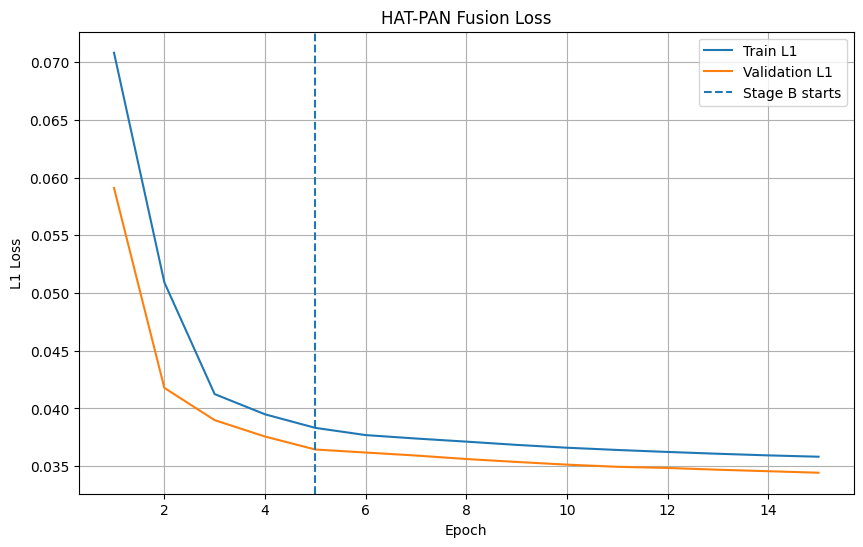

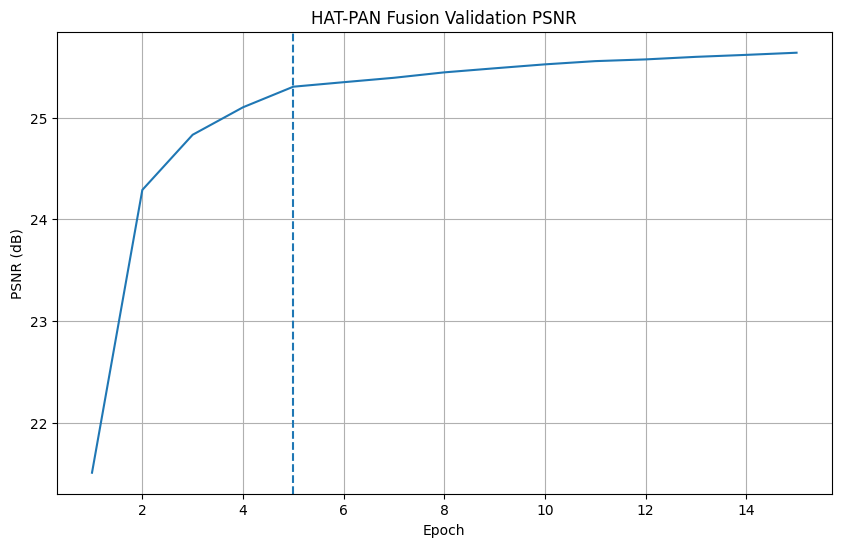

In [17]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history) + 1))

train_losses = [item["train_loss"] for item in history]
val_losses = [item["val_loss"] for item in history]
val_psnr = [item["val_psnr_db"] for item in history]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Train L1")
plt.plot(epochs, val_losses, label="Validation L1")
plt.axvline(STAGE_A_EPOCHS, linestyle="--", label="Stage B starts")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("HAT-PAN Fusion Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_psnr)
plt.axvline(STAGE_A_EPOCHS, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("HAT-PAN Fusion Validation PSNR")
plt.grid()
plt.show()


## 17) Test Evaluation and CNN Comparison

In [18]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

hat_test_metrics = evaluate_model(
    model,
    test_loader,
)

comparison = {
    "hat_pan_fusion_test": hat_test_metrics,
}

if BASELINE_METRICS_PATH.exists():
    with open(BASELINE_METRICS_PATH, "r", encoding="utf-8") as file:
        baseline_metrics = json.load(file)

    comparison["bicubic_test"] = baseline_metrics["bicubic_test"]
    comparison["fusion_cnn_test"] = baseline_metrics["fusion_model_test"]

    comparison["hat_vs_cnn_psnr_db"] = (
        hat_test_metrics["psnr_db"]
        - baseline_metrics["fusion_model_test"]["psnr_db"]
    )

    comparison["hat_vs_cnn_sam_degrees"] = (
        baseline_metrics["fusion_model_test"]["sam_degrees"]
        - hat_test_metrics["sam_degrees"]
    )

with open(TEST_METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(comparison, file, indent=2, ensure_ascii=False)

print(json.dumps(comparison, indent=2, ensure_ascii=False))
print("Saved:", TEST_METRICS_PATH)


Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "hat_pan_fusion_test": {
    "loss": 0.03657697462900118,
    "psnr_db": 24.88978724046187,
    "sam_degrees": 1.9363497495651245
  },
  "bicubic_test": {
    "psnr_db": 18.710798263549805,
    "sam_degrees": 2.6229743162790933
  },
  "fusion_cnn_test": {
    "loss": 0.03530742634426464,
    "psnr_db": 25.076182278719816,
    "sam_degrees": 1.9011461518027566
  },
  "hat_vs_cnn_psnr_db": -0.18639503825794534,
  "hat_vs_cnn_sam_degrees": -0.03520359776236792
}
Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/HAT_PAN_Fusion_Results/hat_test_metrics.json


## 18) Visual Comparison on Test

In [20]:
# تحميل أفضل Checkpoint مرة أخرى
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

test_batch = next(iter(test_loader))

lr_ms = test_batch["lr_ms"].to(
    device,
    dtype=torch.float32,
)

pan = test_batch["pan"].to(
    device,
    dtype=torch.float32,
)

target = test_batch["target_ms"].to(
    device,
    dtype=torch.float32,
)

# مهم: لا نستخدم autocast أو float16 هنا
with torch.inference_mode():
    hat_prediction = model(
        lr_ms,
        pan,
    )

print(
    "Prediction finite:",
    torch.isfinite(hat_prediction).all().item()
)

print(
    "Prediction range:",
    hat_prediction.min().item(),
    "→",
    hat_prediction.max().item()
)

print(
    "NaN count:",
    torch.isnan(hat_prediction).sum().item()
)

print(
    "Inf count:",
    torch.isinf(hat_prediction).sum().item()
)

assert torch.isfinite(hat_prediction).all(), (
    "الناتج ما زال يحتوي على NaN أو Inf."
)

bicubic = F.interpolate(
    lr_ms,
    size=target.shape[-2:],
    mode="bicubic",
    align_corners=False,
).clamp(0, 1)


def rgb321_tensor(tensor):
    rgb = torch.stack(
        [
            tensor[2],
            tensor[1],
            tensor[0],
        ],
        dim=-1,
    )

    rgb = torch.nan_to_num(
        rgb,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    )

    return (
        rgb.float()
        .clamp(0, 1)
        .cpu()
        .numpy()
    )


plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(bicubic[0]))
plt.title("Bicubic")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(
    pan[0, 0].cpu().numpy(),
    cmap="gray",
)
plt.title("PAN Input")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(hat_prediction[0]))
plt.title("HAT-PAN Fusion — Float32")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(target[0]))
plt.title("Ground Truth Target MS")
plt.axis("off")
plt.show()

print("Test file:", test_batch["file"][0])

Output hidden; open in https://colab.research.google.com to view.

# المطلوب بعد التشغيل

أرسل:

1. نتائج Stage A.
2. نتائج Stage B.
3. JSON المقارنة النهائي بين:
   - Bicubic.
   - Fusion CNN.
   - HAT-PAN Fusion.
4. صور HAT Prediction وTarget.

## التفسير الصحيح

هذه النتائج تقيس الأداء عند **Reduced Resolution**:

```text
4.8 m MS + 1.2 m PAN → 1.2 m MS
```

وهي الطريقة التي نملك فيها Target حقيقية.

لا تعني وحدها أن الصورة النهائية الناتجة عند `0.3 m` لها Ground Truth مؤكدة. بعد اختيار أفضل نموذج، سنشغّله على:

```text
Original MS 1.2 m + Original PAN 0.3 m
→ Predicted MS 0.3 m
```

ثم نستخدم No-Reference Pansharpening Metrics وتقييمًا بصريًا.
